# Import necessary librairies and load preprocessed data

In [1]:
# Import necessary libraries
import cv2
import numpy as np
from skimage.feature import local_binary_pattern, hog
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
import os
import glob
from sklearn.cluster import KMeans
from scipy.cluster.vq import vq
from skimage.filters import gabor
from sklearn.mixture import GaussianMixture

In [2]:
# Load preprocessed data
X_train = np.load('../datasets/dataset5/X_train.npy') #c:/Users/HP/Desktop/sign_verif
y_train = np.load('../datasets/dataset5/y_train.npy')
X_test = np.load('../datasets/dataset5/X_test.npy')
y_test = np.load('../datasets/dataset5/y_test.npy')

In [3]:
# Set parameters for feature extraction
SIZE = 224
radius = 3
n_points = 8 * radius

# LBP

In [284]:
def extract_lbp_features(images):
    radius = 3
    n_points = 8 * radius
    lbp_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE)
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
        lbp_hist = lbp_hist.astype('float')
        lbp_hist /= (lbp_hist.sum() + 1e-6)
        lbp_features.append(lbp_hist)
    return np.array(lbp_features)


# https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.local_binary_pattern

In [285]:
lbp_train = extract_lbp_features(X_train)
lbp_test = extract_lbp_features(X_test)

In [287]:
# Function to visualize LBP features
def visualize_lbp_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(lbp, cmap='gray')
    plt.title('LBP Features')
    plt.axis('off')

    plt.show()

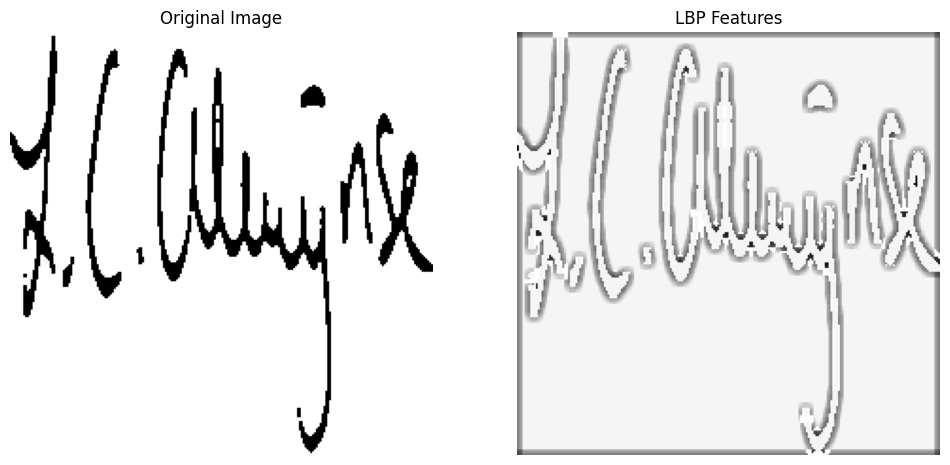

In [288]:
visualize_lbp_features(X_train, index=25)

In [289]:
def visualize_lbp_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype('float')
    lbp_hist /= (lbp_hist.sum() + 1e-6)

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(lbp_hist)), lbp_hist, width=0.6, color='black')
    plt.title('Histogram of LBP Features')
    plt.xlabel('LBP Bins')
    plt.ylabel('Frequency')
    plt.show()

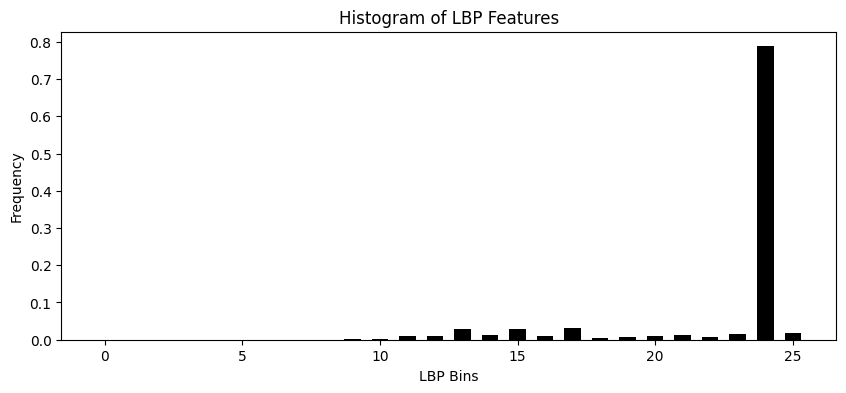

In [290]:
visualize_lbp_histogram(X_train, index=0)

# LDP

In [291]:
def extract_ldp_features(images):
    ldp_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE)
        ldp = np.zeros_like(img)
        
        # Calculate LDP for each pixel
        for i in range(1, img.shape[0] - 1):
            for j in range(1, img.shape[1] - 1):
                center = img[i, j]
                code = 0
                if img[i-1, j-1] >= center: code |= 1 << 0
                if img[i-1, j] >= center: code |= 1 << 1
                if img[i-1, j+1] >= center: code |= 1 << 2
                if img[i, j+1] >= center: code |= 1 << 3
                if img[i+1, j+1] >= center: code |= 1 << 4
                if img[i+1, j] >= center: code |= 1 << 5
                if img[i+1, j-1] >= center: code |= 1 << 6
                if img[i, j-1] >= center: code |= 1 << 7
                ldp[i, j] = code

        ldp_hist, _ = np.histogram(ldp, bins=np.arange(0, 256), range=(0, 255))
        ldp_hist = ldp_hist.astype('float')
        ldp_hist /= (ldp_hist.sum() + 1e-6)
        ldp_features.append(ldp_hist)
    
    return np.array(ldp_features)


In [292]:
ldp_train = extract_ldp_features(X_train)
ldp_test = extract_ldp_features(X_test)

In [293]:
def visualize_ldp_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    ldp = np.zeros_like(img)

    # Calculate LDP for each pixel
    for i in range(1, img.shape[0] - 1):
        for j in range(1, img.shape[1] - 1):
            center = img[i, j]
            code = 0
            if img[i-1, j-1] >= center: code |= 1 << 0
            if img[i-1, j] >= center: code |= 1 << 1
            if img[i-1, j+1] >= center: code |= 1 << 2
            if img[i, j+1] >= center: code |= 1 << 3
            if img[i+1, j+1] >= center: code |= 1 << 4
            if img[i+1, j] >= center: code |= 1 << 5
            if img[i+1, j-1] >= center: code |= 1 << 6
            if img[i, j-1] >= center: code |= 1 << 7
            ldp[i, j] = code

    plt.figure(figsize=(12, 6))

    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Display LDP image
    plt.subplot(1, 2, 2)
    plt.imshow(ldp, cmap='gray')
    plt.title('LDP Features')
    plt.axis('off')

    plt.show()

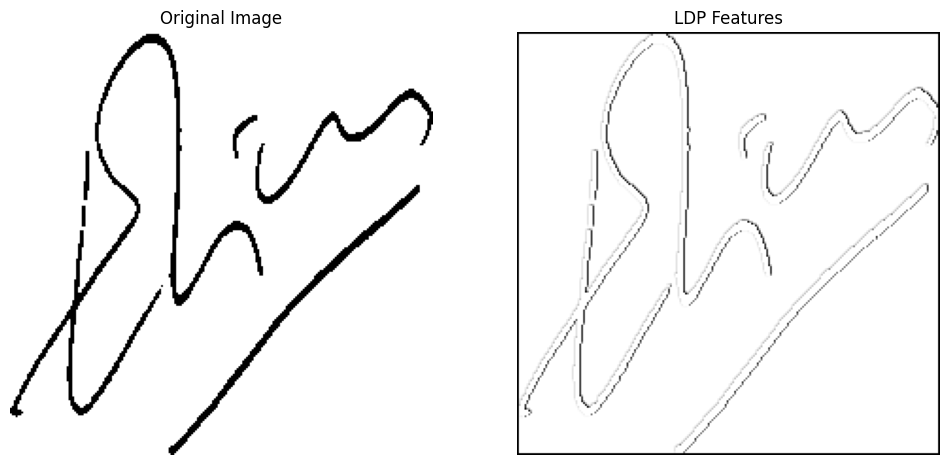

In [294]:
visualize_ldp_features(X_train, index=0)

In [295]:
def visualize_ldp_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    ldp = np.zeros_like(img)

    # Calculate LDP for each pixel
    for i in range(1, img.shape[0] - 1):
        for j in range(1, img.shape[1] - 1):
            center = img[i, j]
            code = 0
            if img[i-1, j-1] >= center: code |= 1 << 0
            if img[i-1, j] >= center: code |= 1 << 1
            if img[i-1, j+1] >= center: code |= 1 << 2
            if img[i, j+1] >= center: code |= 1 << 3
            if img[i+1, j+1] >= center: code |= 1 << 4
            if img[i+1, j] >= center: code |= 1 << 5
            if img[i+1, j-1] >= center: code |= 1 << 6
            if img[i, j-1] >= center: code |= 1 << 7
            ldp[i, j] = code

    ldp_hist, _ = np.histogram(ldp, bins=np.arange(0, 256), range=(0, 255))
    ldp_hist = ldp_hist.astype('float')
    ldp_hist /= (ldp_hist.sum() + 1e-6)

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(ldp_hist)), ldp_hist, width=0.6, color='black')
    plt.title('Histogram of LDP Features')
    plt.xlabel('LDP Bins')
    plt.ylabel('Frequency')
    plt.show()


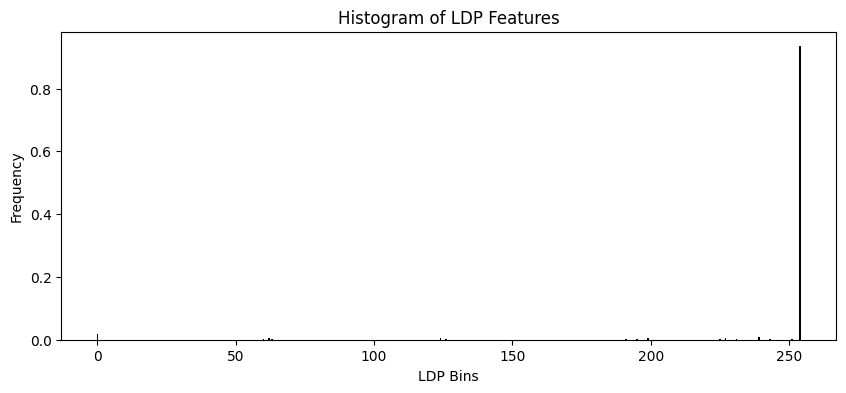

In [296]:
visualize_ldp_histogram(X_train, index=0)

# HOG

In [4]:
def extract_hog_features(images):
    hog_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE)
        features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
        hog_features.append(features)
    return np.array(hog_features)

# https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog

In [299]:
hog_train = extract_hog_features(X_train)
hog_test = extract_hog_features(X_test)

In [5]:
# Function to visualize HOG features
def visualize_hog_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(hog_image, cmap='gray')
    plt.title('HOG Features')
    plt.axis('off')

    plt.show()

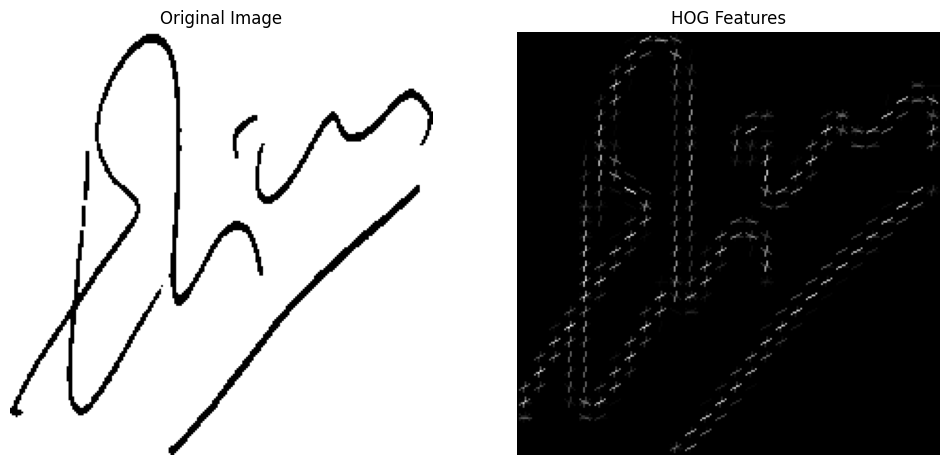

In [9]:
visualize_hog_features(X_train, index=0)

In [302]:
def visualize_hog_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    
    plt.figure(figsize=(10, 4))
    plt.hist(features, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of HOG Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

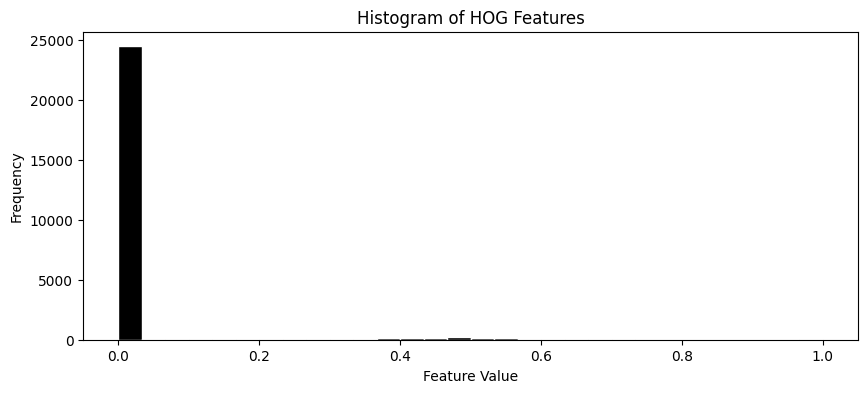

In [303]:
visualize_hog_histogram(X_train, index=0)


# SIFT

In [304]:
# Check OpenCV version for feature extractor compatibility
if int(cv2.__version__.split('.')[0]) >= 4:
    sift = cv2.SIFT_create()
else:
    sift = cv2.xfeatures2d.SIFT_create()

In [305]:
def extract_sift_features(images):
    sift_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        keypoints, descriptors = sift.detectAndCompute(img, None)
        if descriptors is not None:
            descriptors = descriptors.flatten()
            descriptors = descriptors[:SIZE * SIZE]  # Limiter la longueur pour uniformiser
            if len(descriptors) < SIZE * SIZE:
                descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
        else:
            descriptors = np.zeros(SIZE * SIZE)
        sift_features.append(descriptors)
    return np.array(sift_features)

In [306]:
sift_train = extract_sift_features(X_train)
sift_test = extract_sift_features(X_test)

In [307]:
def visualize_sift_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')

    keypoints, descriptors = sift.detectAndCompute(img, None)

    img_sift = cv2.drawKeypoints(img, keypoints, None)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_sift, cmap='gray')
    plt.title('SIFT Features')
    plt.axis('off')

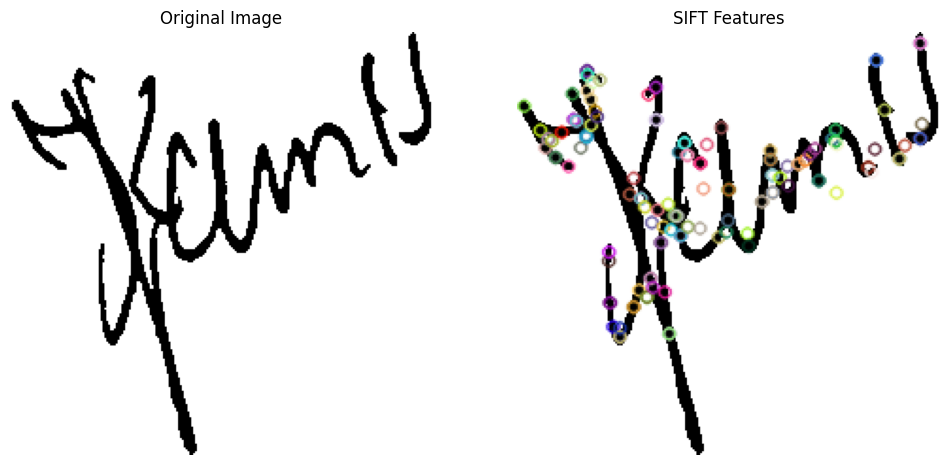

In [308]:
visualize_sift_features(X_train, index=79)

In [309]:
def visualize_sift_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    keypoints, descriptors = sift.detectAndCompute(img, None)
    if descriptors is not None:
        descriptors = descriptors.flatten()
        descriptors = descriptors[:SIZE * SIZE]  # Limiter la longueur pour uniformiser
        if len(descriptors) < SIZE * SIZE:
            descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
    else:
        descriptors = np.zeros(SIZE * SIZE)

    plt.figure(figsize=(10, 4))
    plt.hist(descriptors, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of SIFT Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

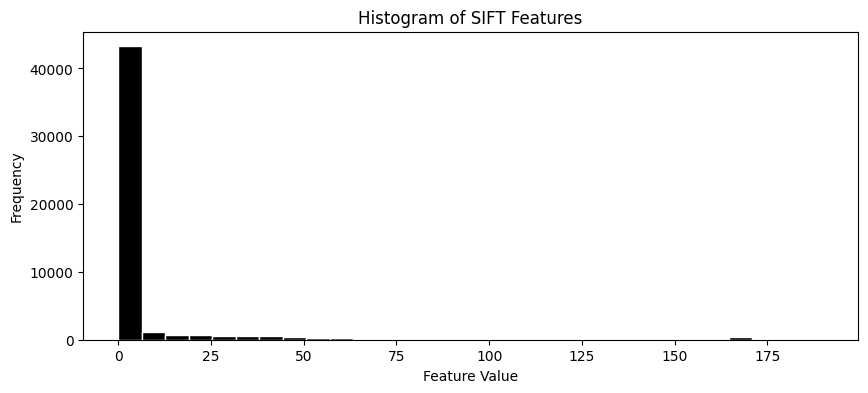

In [310]:
visualize_sift_histogram(X_train, index=0)

# ORB

In [5]:
# Check OpenCV version for feature extractor compatibility
if int(cv2.__version__.split('.')[0]) >= 4:
    orb = cv2.ORB_create()
else:
    orb = cv2.ORB_create()

In [6]:
def extract_orb_features(images):
    orb_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        keypoints, descriptors = orb.detectAndCompute(img, None)
        if descriptors is not None:
            descriptors = descriptors.flatten()
            descriptors = descriptors[:SIZE * SIZE]  # Limiter la longueur pour uniformiser
            if len(descriptors) < SIZE * SIZE:
                descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
        else:
            descriptors = np.zeros(SIZE * SIZE)
        orb_features.append(descriptors)
    return np.array(orb_features)

In [312]:
orb_train = extract_orb_features(X_train)
orb_test = extract_orb_features(X_test)

In [313]:
# Function to visualize ORB features
def visualize_orb_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    keypoints, descriptors = orb.detectAndCompute(img, None)

    img_orb = cv2.drawKeypoints(img, keypoints, None)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_orb, cmap='gray')
    plt.title('ORB Features')
    plt.axis('off')
    plt.show()

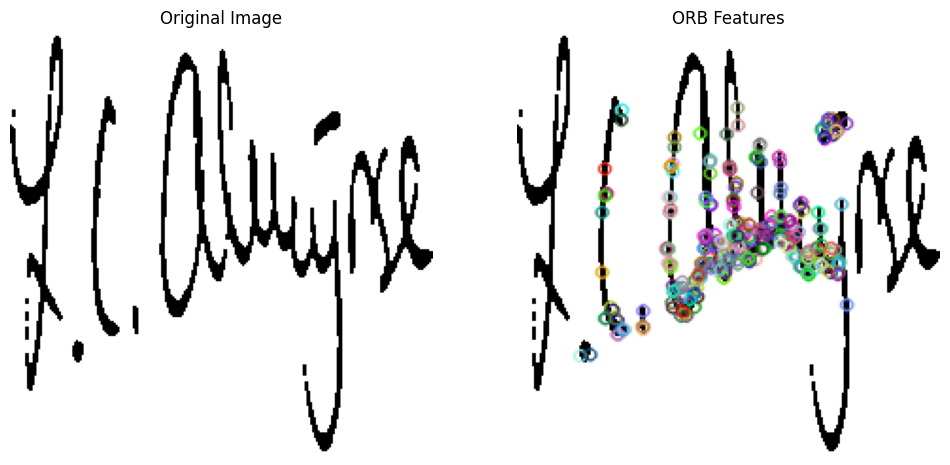

In [314]:
visualize_orb_features(X_train, index=45)

In [315]:
# Function to visualize ORB histogram
def visualize_orb_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    keypoints, descriptors = orb.detectAndCompute(img, None)
    if descriptors is not None:
        descriptors = descriptors.flatten()
        descriptors = descriptors[:SIZE * SIZE]
        if len(descriptors) < SIZE * SIZE:
            descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
    else:
        descriptors = np.zeros(SIZE * SIZE)

    plt.figure(figsize=(10, 4))
    plt.hist(descriptors, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of ORB Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()


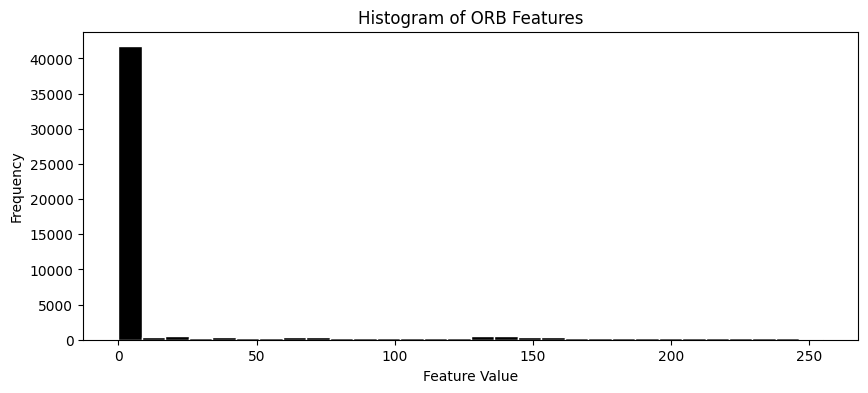

In [316]:
visualize_orb_histogram(X_train, index=5)

# BRIEF

In [317]:
# Function to extract BRIEF features
# Use ORB as a replacement for BRIEF keypoint detector
def extract_brief_features(images):
    brief_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        keypoints = orb.detect(img, None)
        keypoints, descriptors = orb.compute(img, keypoints)
        if descriptors is not None:
            descriptors = descriptors.flatten()
            descriptors = descriptors[:SIZE * SIZE]
            if len(descriptors) < SIZE * SIZE:
                descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
        else:
            descriptors = np.zeros(SIZE * SIZE)
        brief_features.append(descriptors)
    return np.array(brief_features)


In [318]:
brief_train = extract_brief_features(X_train)
brief_test = extract_brief_features(X_test)

In [319]:
# Function to visualize BRIEF features
def visualize_brief_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    keypoints = orb.detect(img, None)
    keypoints, descriptors = orb.compute(img, keypoints)

    img_brief = cv2.drawKeypoints(img, keypoints, None)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_brief, cmap='gray')
    plt.title('BRIEF Features')
    plt.axis('off')
    plt.show()

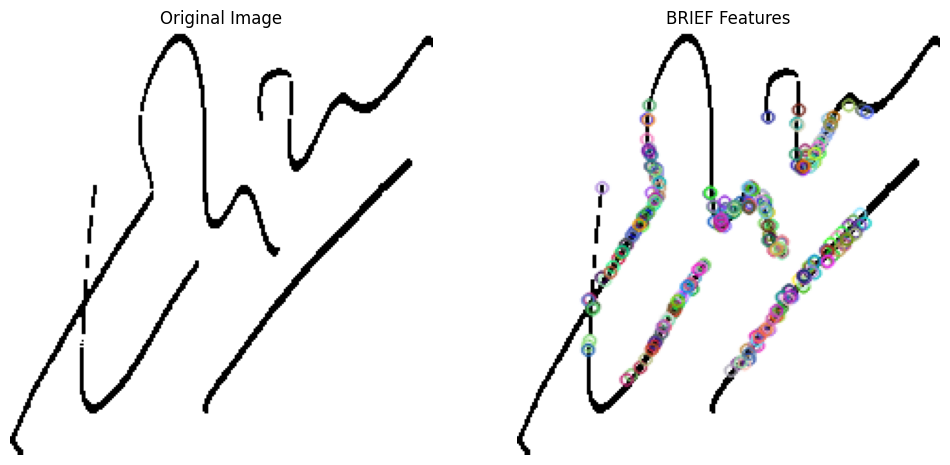

In [320]:
visualize_brief_features(X_train, index=4)

In [321]:
# Function to visualize BRIEF histogram
def visualize_brief_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    keypoints = orb.detect(img, None)
    keypoints, descriptors = orb.compute(img, keypoints)
    if descriptors is not None:
        descriptors = descriptors.flatten()
        descriptors = descriptors[:SIZE * SIZE]
        if len(descriptors) < SIZE * SIZE:
            descriptors = np.pad(descriptors, (0, SIZE * SIZE - len(descriptors)), 'constant')
    else:
        descriptors = np.zeros(SIZE * SIZE)

    plt.figure(figsize=(10, 4))
    plt.hist(descriptors, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of BRIEF Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

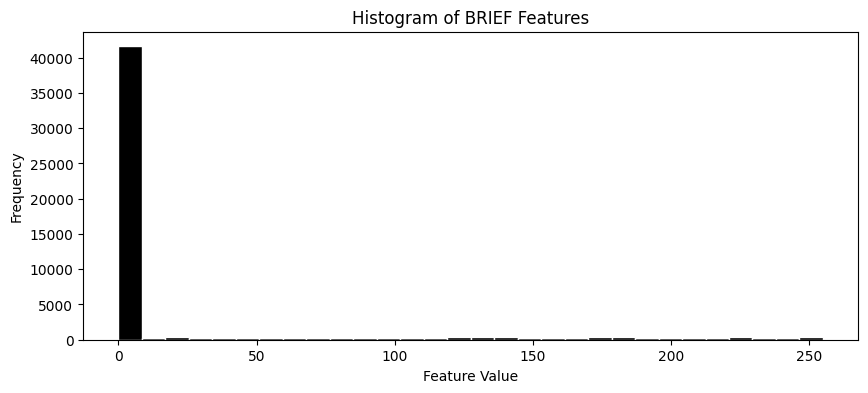

In [322]:
visualize_brief_histogram(X_train, index=30)

# GABOR

In [323]:
def extract_gabor_features(images):
    gabor_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE)
        filt_real, filt_imag = gabor(img, frequency=0.6)
        gabor_features.append(filt_real.flatten())
    return np.array(gabor_features)

In [324]:
gabor_train = extract_gabor_features(X_train)
gabor_test = extract_gabor_features(X_test)

In [325]:
# Function to visualize Gabor features
def visualize_gabor_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    filt_real, filt_imag = gabor(img, frequency=0.6)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(filt_real, cmap='gray')
    plt.title('Gabor Features')
    plt.axis('off')
    plt.show()

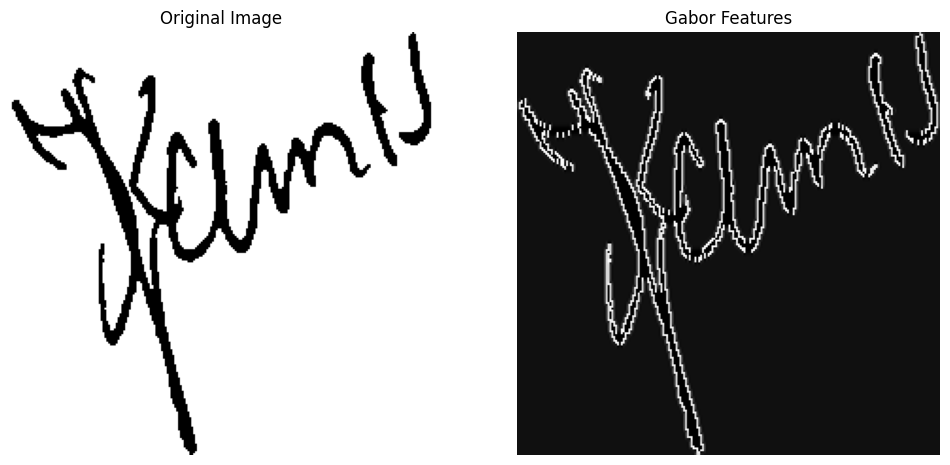

In [326]:
visualize_gabor_features(X_train, index=79)

In [327]:
# Function to visualize Gabor histogram
def visualize_gabor_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE)
    filt_real, filt_imag = gabor(img, frequency=0.6)

    plt.figure(figsize=(10, 4))
    plt.hist(filt_real.flatten(), bins=30, color='black', edgecolor='white')
    plt.title('Histogram of Gabor Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

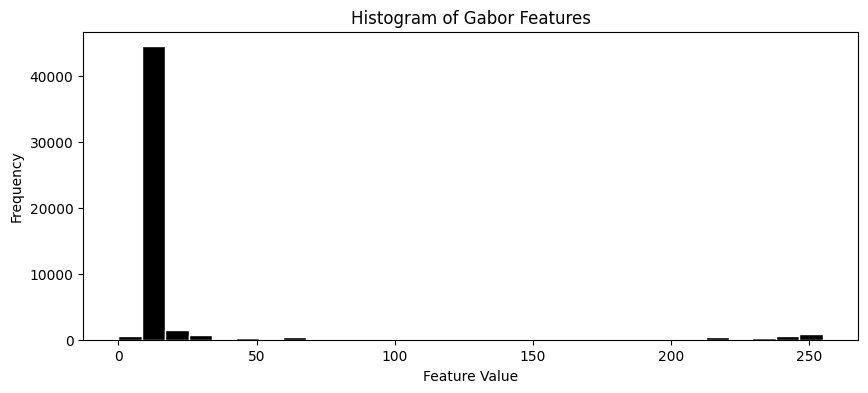

In [328]:
visualize_gabor_histogram(X_train, index=20)

# GLCM

In [329]:
def extract_glcm_features(images, distances=[1], angles=[0]):
    glcm_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        glcm = graycomatrix(img, distances=distances, angles=angles, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast').flatten()
        dissimilarity = graycoprops(glcm, 'dissimilarity').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()
        asm = graycoprops(glcm, 'ASM').flatten()
        features = np.hstack([contrast, dissimilarity, homogeneity, energy, correlation, asm])
        glcm_features.append(features)
    return np.array(glcm_features)

In [330]:
glcm_train = extract_glcm_features(X_train)
glcm_test = extract_glcm_features(X_test)

In [331]:
def visualize_glcm_features(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    glcm = graycomatrix(img, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    asm = graycoprops(glcm, 'ASM')[0, 0]

    plt.figure(figsize=(20, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation', 'ASM'], 
            [contrast, dissimilarity, homogeneity, energy, correlation, asm], color='black')
    plt.title('GLCM Features')
    plt.xlabel('Properties')
    plt.ylabel('Values')
    plt.show()


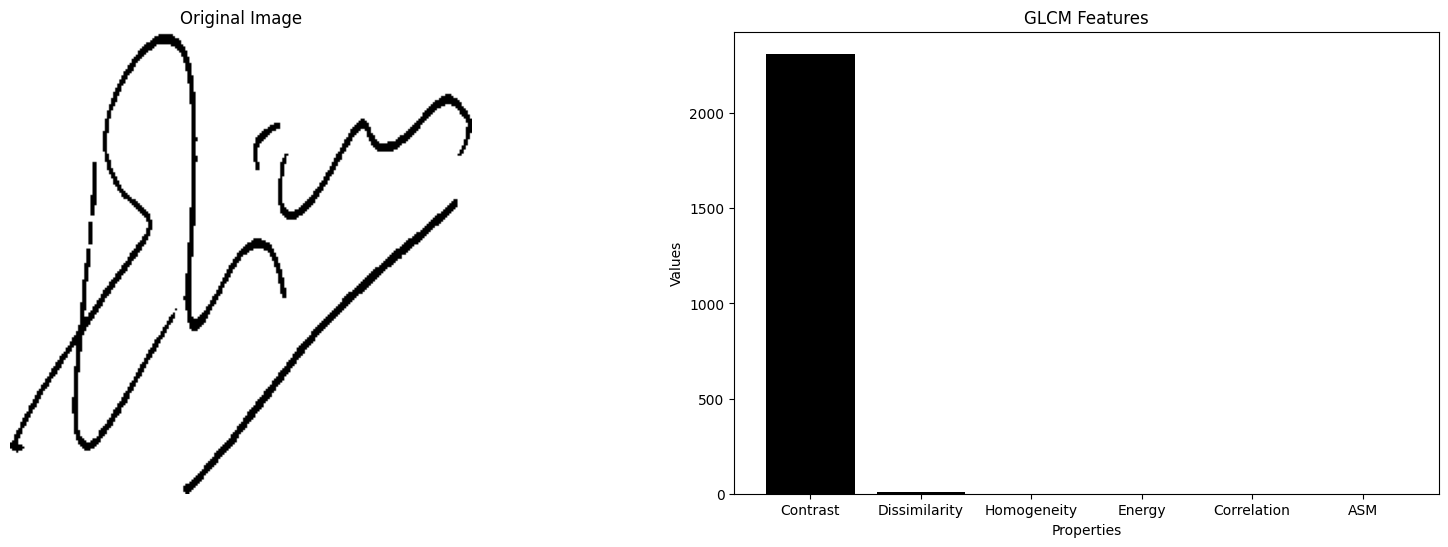

In [332]:
visualize_glcm_features(X_train, index=0)

In [333]:
def visualize_glcm_histogram(images, index=0):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    glcm = graycomatrix(img, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').flatten()
    dissimilarity = graycoprops(glcm, 'dissimilarity').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    asm = graycoprops(glcm, 'ASM').flatten()

    features = np.hstack([contrast, dissimilarity, homogeneity, energy, correlation, asm])

    plt.figure(figsize=(10, 4))
    plt.hist(features, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of GLCM Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

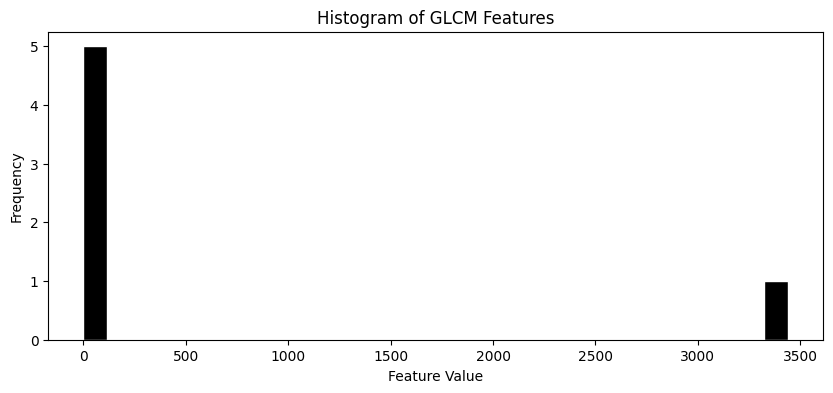

In [334]:
visualize_glcm_histogram(X_train, index=30)

# VLAD

In [10]:
def extract_sift_descriptors(images):
    sift = cv2.SIFT_create()
    all_descriptors = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        keypoints, descriptors = sift.detectAndCompute(img, None)
        if descriptors is not None:
            all_descriptors.append(descriptors)
    return all_descriptors

def form_codebook(descriptors_list, k):
    all_descriptors = np.vstack(descriptors_list)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(all_descriptors)
    return kmeans.cluster_centers_

def compute_vlad(descriptors, codebook):
    k = codebook.shape[0]
    n = codebook.shape[1]
    vlad = np.zeros((k, n), dtype=np.float32)
    
    if descriptors is None or len(descriptors) == 0:
        return vlad.flatten()
    
    kmeans = KMeans(n_clusters=k, random_state=0).fit(codebook)
    labels = kmeans.predict(descriptors)
    
    for i in range(k):
        if np.sum(labels == i) > 0:
            vlad[i] = np.sum(descriptors[labels == i] - codebook[i], axis=0)
    
    vlad = vlad.flatten()
    vlad = np.sign(vlad) * np.sqrt(np.abs(vlad))  # RootSIFT-like normalization
    vlad = vlad / np.linalg.norm(vlad)  # L2 normalization
    return vlad

def extract_vlad_features(images, codebook):
    sift = cv2.SIFT_create()
    vlad_features = []
    for img in images:
        img = img.reshape(SIZE, SIZE).astype('uint8')
        keypoints, descriptors = sift.detectAndCompute(img, None)
        vlad = compute_vlad(descriptors, codebook)
        vlad_features.append(vlad)
    return np.array(vlad_features)

In [11]:
sift_descriptors = extract_sift_descriptors(X_train)
codebook = form_codebook(sift_descriptors, k=64)
vlad_train = extract_vlad_features(X_train, codebook)
vlad_test = extract_vlad_features(X_test, codebook)

In [14]:
# Fonction pour visualiser les caractéristiques VLAD
def visualize_vlad_features(images, index=0, codebook=None):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    
    if codebook is None:
        raise ValueError("Le codebook doit être fourni pour calculer les caractéristiques VLAD.")
    
    vlad = compute_vlad(descriptors, codebook)

    img_sift = cv2.drawKeypoints(img, keypoints, None)

    plt.figure(figsize=(20, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(np.arange(len(vlad)), vlad, width=0.6, color='black')
    plt.title('VLAD Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Feature Value')
    plt.show()

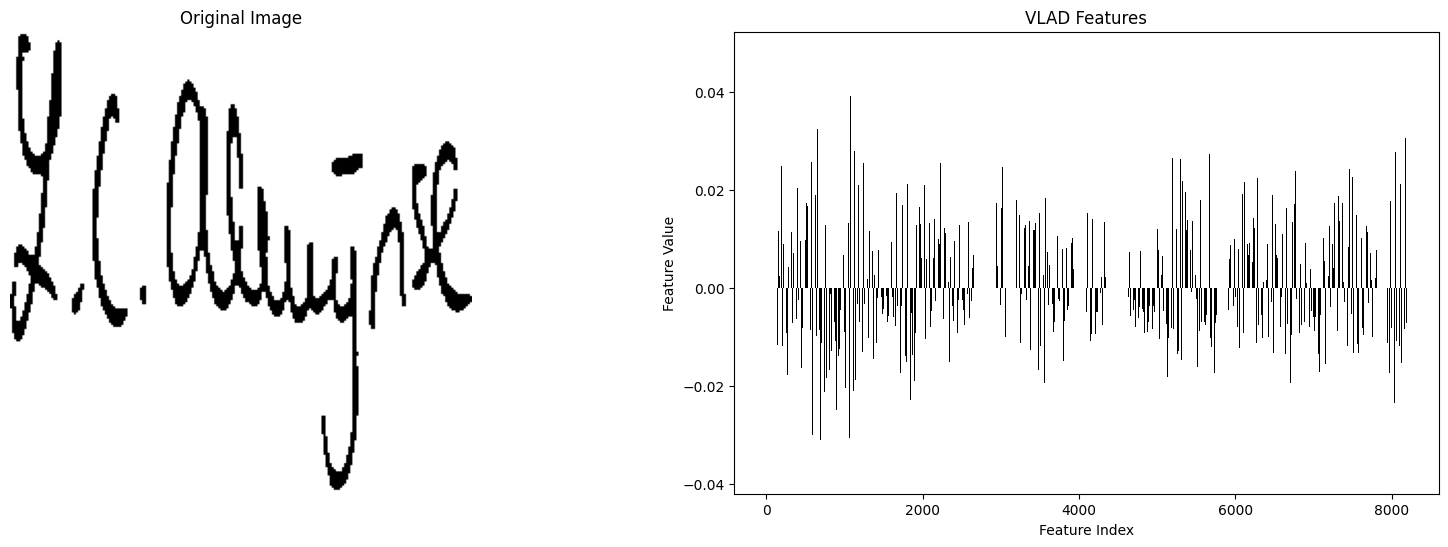

In [15]:
sift_descriptors = extract_sift_descriptors(X_train)
codebook = form_codebook(sift_descriptors, k=64)
visualize_vlad_features(X_train, index=30, codebook=codebook)

In [339]:
# Fonction pour visualiser l'histogramme des caractéristiques VLAD
def visualize_vlad_histogram(images, index=0, codebook=None):
    img = images[index].reshape(SIZE, SIZE).astype('uint8')
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    
    if codebook is None:
        raise ValueError("Le codebook doit être fourni pour calculer les caractéristiques VLAD.")
    
    vlad = compute_vlad(descriptors, codebook)

    plt.figure(figsize=(10, 4))
    plt.hist(vlad, bins=30, color='black', edgecolor='white')
    plt.title('Histogram of VLAD Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.show()

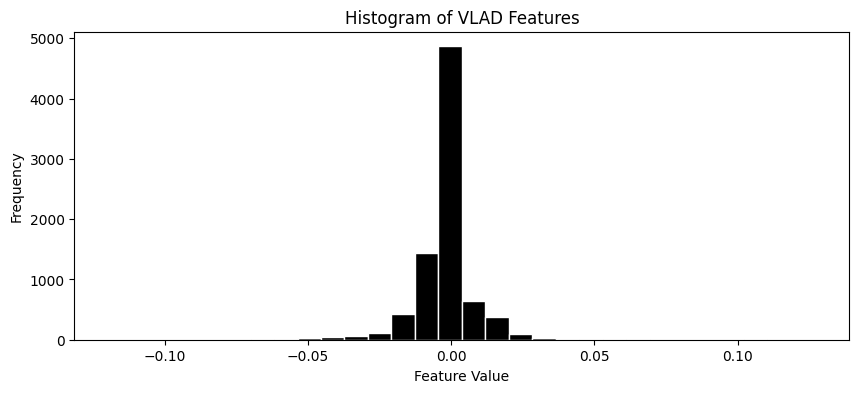

In [340]:
visualize_vlad_histogram(X_train, index=0, codebook=codebook)

# Combine and save extracted features

In [341]:
# Combine LBP, HOG, SIFT, and SURF features
X_train_features = np.hstack((lbp_train, hog_train, sift_train, ldp_train, orb_train, gabor_train , glcm_train , vlad_train))
X_test_features = np.hstack((lbp_test, hog_test, sift_test, ldp_test, orb_test, gabor_test,glcm_test ,vlad_test))

In [342]:
# Save extracted features
np.save('../datasets/dataset5/X_train_features.npy', X_train_features)
np.save('../datasets/dataset5/X_test_features.npy', X_test_features)

print("Extraction des caractéristiques terminée et données sauvegardées.")

Extraction des caractéristiques terminée et données sauvegardées.


In [343]:
# Combine  ORB, SIFT, and BRIEF features
X_train_Local_Descriptors = np.hstack((sift_train, orb_train, brief_train))
X_test_Local_Descriptors = np.hstack((sift_test, orb_test, brief_test))

In [344]:
np.save('../datasets/dataset5/X_train_Local_Descriptors.npy', X_train_Local_Descriptors)
np.save('../datasets/dataset5/X_test_Local_Descriptors.npy', X_test_Local_Descriptors)

In [345]:
X_train_Texture_Analysis = np.hstack((lbp_train, ldp_train, gabor_train , glcm_train))
X_test_Texture_Analysis = np.hstack((lbp_test, ldp_test, gabor_test,glcm_test ))

In [346]:
np.save('../datasets/dataset5/X_train_Texture_Analysis.npy', X_train_Texture_Analysis)
np.save('../datasets/dataset5/X_test_Texture_Analysis.npy', X_test_Texture_Analysis)

In [348]:
np.save('../datasets/dataset5/X_train_Aggregation_Descriptors.npy', vlad_train)
np.save('../datasets/dataset5/X_test_Aggregation_Descriptors.npy', vlad_test)

In [350]:
np.save('../datasets/dataset5/X_train_Shape_Contour_Analysis.npy', hog_train)
np.save('../datasets/dataset5/X_test_Shape_Contour_Analysis.npy', hog_test)